# Momentum-based Gradient Descent 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Defining a quadratic loss function
x and y here are not input and output, they are **two parameters** in a loss function.

$L = x^{2} + 10y^{2}$

In [2]:
def quadratic_loss(x, y):
    return x**2 + 10 * y**2 #Ellipse

## Gradient of the loss function

$\partial x = 2x$ and $\partial y = 20y$

In [3]:
def quadratic_grad(x, y):
    dx = 2*x
    dy = 20*y
    return np.array([dx, dy])

## Batch Gradient Descent (BGD)

- eta: $\eta$ is the learning rate.

In [4]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
    x, y = start_point
    path = [(x, y)]
    losses = [quadratic_loss(x, y)]

    for _ in range(epochs):
        grad = grad_func(x,y)
        x -= eta*grad[0] #Partial Derivative to x
        y -= eta*grad[1] #Partial derivative to y
        path.append((x,y))
        losses.append(quadratic_loss(x,y))

    return np.array(path), losses

## Gradient Descent with Momentum

- Velocity: $v = \beta * v + (1-\beta) * grad$

In [5]:
def gradient_descent_momentum(grad_func, eta, beta, epochs, start_point):
    x, y = start_point
    path = [(x,y)]
    losses = [quadratic_loss(x,y)]
    v=0

    for _ in range(epochs):
        grad = grad_func(x,y)
        v = beta * v + (1-beta)*grad # Velocity
        x -= eta*v[0] #Partial derivative to x
        y -= eta*v[1] #Partial derivatice to y
        path.append((x,y))
        losses.append(quadratic_loss(x,y))

    return np.array(path), losses

## Parameters

In [6]:
eta_bgd = 0.1 # Learning rate for BGD
eta_momentum = 0.1 #Learning rate for momentum
beta = 0.9 # Momentum coefficient
epochs = 50
start_point = (1.5, 1.5) # Inital point far from the minimum

## Plot results

### `np.meshgrid()`

- Accepts any 1D arrays representing the coordinates of a grid

- Return a tuple of coordinate matrices from coordinate vectors. (Turns coordinate arrays into meshgrid)

#### Meshgrid

A coordinate grid is a set of regularly arranged points formed by combining x-values and y-values. For example:

```Python
x = [1, 2, 3]
y = [10, 20]
```
Corresponds to meshgrid:
```Plain Text
(1,10)   (2,10)   (3,10)
(1,20)   (2,20)   (3,20)
```
Converted to two matrices
```Python
X =
[[1, 2, 3],
 [1, 2, 3]]

Y =
[[10, 10, 10],
 [20, 20, 20]]
```
Number is represented in as the coordinate in the matrix

`(2,3)` in this case
```Python
X[1, 2] = 3
Y[1, 2] = 20
```

### `zip()`

```Python
a = ("John", "Charles", "Mike")
b = ("Jenny", "Christy", "Monica")

x = zip(a, b)
```
```Plain Text
(('John', 'Jenny'), ('Charles', 'Christy'), ('Mike', 'Monica'))
```

In [ ]:
def plot_paths(function, paths, labels, title):
    X, Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    Z = function(X, Y)

    plt.figure(figsize=(8,6))
    plt.contour(X, Y, Z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label) # Path
        plt.scatter(path[0, 0], path[0, 1], color='green', label='Start') # Starting point
        plt.scatter(path[-1, 0], path[-1, 1], color='red', label='End') # Ending point

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

In [8]:
def plot_losses(losses, labels, title):
    plt.figure(figsize=(8,6))
    
    for loss, label in zip(losses, labels):
        plt.plot(loss, label=label)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()
    

## Run optimizations

In [9]:
path_bgd, losses_bgd = batch_gradient_descent(quadratic_grad, eta_bgd, epochs, start_point)
path_momentum, losses_momentum = gradient_descent_momentum(quadratic_grad, eta_momentum, beta, epochs, start_point)

## Plotting the optimized results

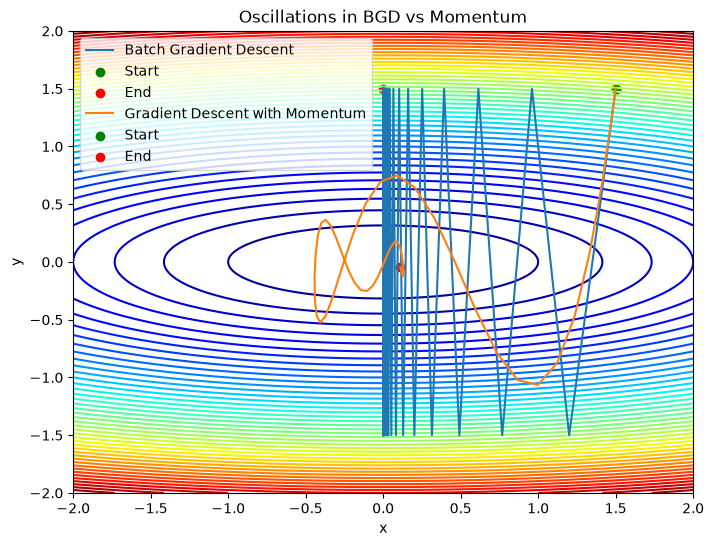

In [10]:
plot_paths(quadratic_loss, [path_bgd, path_momentum], ["Batch Gradient Descent", "Gradient Descent with Momentum"], "Oscillations in BGD vs Momentum")